In [1]:
# I need these tools:
# - Path: makes working with file/folder locations easier
# - numpy: turns images into number grids that models can read
# - PIL Image: opens and resizes image files
# - matplotlib: shows images and graphs on screen

from pathlib import Path
from typing import List, Tuple

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Set up my folder structure:
# - Project_Root: the main project folder (one level up from this notebook)
# - Data_DIR: where all data lives
# - Raw_DIR: original untouched images go here
# - Derived_DIR: processed/saved outputs go here
# mkdir creates the folder if it doesn't exist yet

Project_Root = Path("..")
Project_Root.resolve()
Data_DIR = Project_Root / "data"
Data_DIR.mkdir(exist_ok = True)

Raw_DIR = Data_DIR / "raw"
Raw_DIR.mkdir(exist_ok = True)

Derived_DIR = Data_DIR / "derived"
Derived_DIR.mkdir(exist_ok = True)


In [3]:
# Find every .bmp image file inside Raw_DIR (including subfolders)
# Store all the file paths in a list
# Print how many I found

Image_Paths = list(Raw_DIR.rglob("*.bmp"))
len(Image_Paths)

1204

In [4]:
# Grab the first image path so I can examine one example

Example_Path = Image_Paths[0]
Example_Path

PosixPath('../data/raw/Image_Data/abn_all/frame0416.bmp')

In [5]:
# Count how many images are in each subfolder
# This tells me my class names and how many images per class

from collections import Counter

folder_counts = Counter(p.parent.name for p in Image_Paths)
folder_counts


Counter({'abn_all': 600, 'n_all': 600, '.ipynb_checkpoints': 4})

In [6]:
# Remove any paths that contain '.ipynb_checkpoints'
# Those are Jupyter backup files, not real data

Image_Paths = [p for p in Image_Paths if '.ipynb_checkpoints' not in str(p)]
len(Image_Paths)

1200

In [7]:
# Get a clean list of class names (folder names)
# Sort them so the order is always the same

CLASS_NAMES = sorted(folder_counts.keys() - {'.ipynb_checkpoints'})
CLASS_NAMES

['abn_all', 'n_all']

In [8]:
# Open one image and look at its properties:
# - Format: what type of file (BMP)
# - Mode: color or grayscale
# - Size: width and height in pixels
# - Array shape: dimensions when converted to numbers
# - Pixel range: min and max values (should be 0-255)

sample_img = Image.open(Example_Path)
sample_array = np.array(sample_img)

print(f"Format: {sample_img.format}")
print(f"Mode: {sample_img.mode}")
print(f"Size: {sample_img.size}")
print(f"Array shape: {sample_array.shape}")
print(f"Pixel range: [{sample_array.min()}, {sample_array.max()}]")

Format: BMP
Mode: L
Size: (120, 120)
Array shape: (120, 120)
Pixel range: [0, 255]


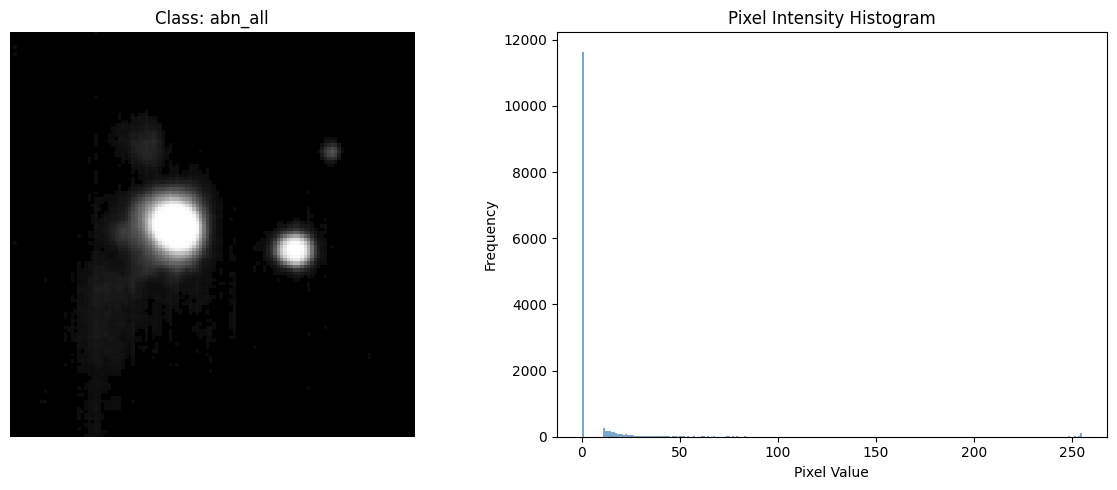

In [9]:
# Show the sample image on the left
# Show a histogram on the right (how often each brightness level appears)
# This helps me see if the image looks normal

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sample_array, cmap='gray' if sample_array.ndim == 2 else None)
axes[0].set_title(f"Class: {Example_Path.parent.name}")
axes[0].axis('off')

axes[1].hist(sample_array.ravel(), bins=256, color='steelblue', alpha=0.7)
axes[1].set_title('Pixel Intensity Histogram')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Organize images by class
# Create a dictionary where:
# - key = class name (like 'abn_all')
# - value = list of image paths in that class

images_by_class = {}
for p in Image_Paths:
    class_name = p.parent.name
    if class_name not in images_by_class:
        images_by_class[class_name] = []
    images_by_class[class_name].append(p)

{k: len(v) for k, v in images_by_class.items()}

{'abn_all': 600, 'n_all': 600}

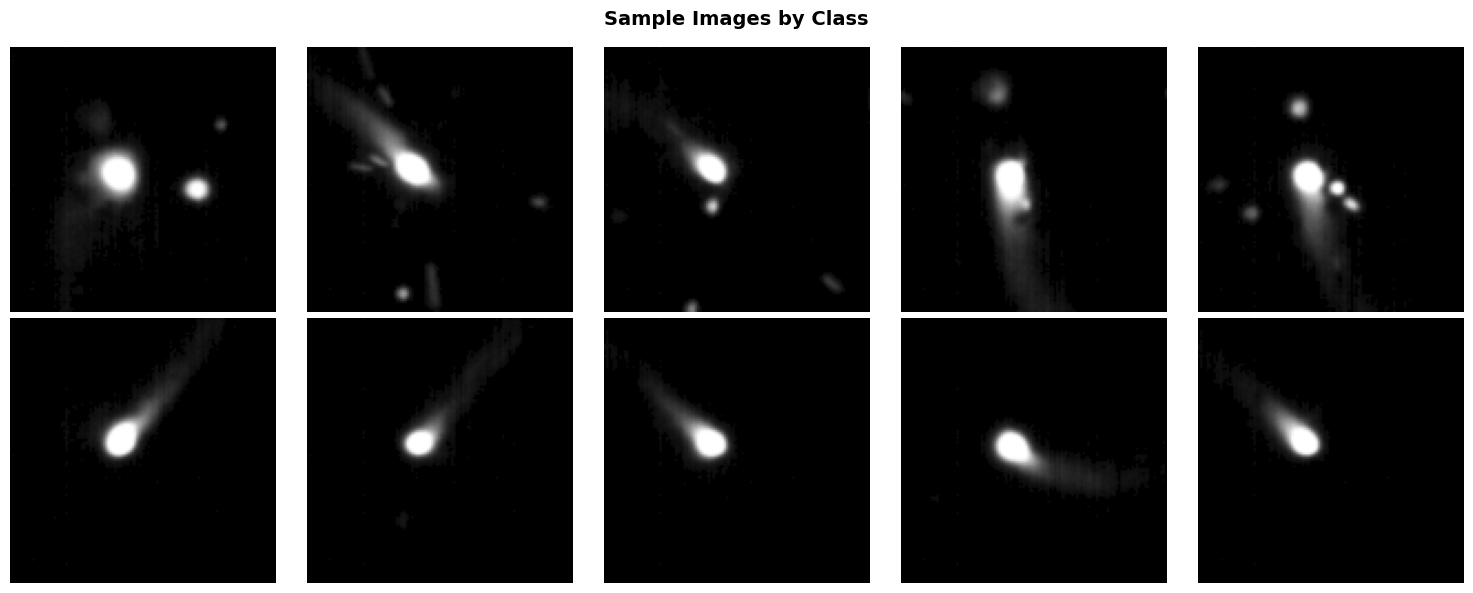

In [11]:
# Show a grid of sample images
# One row per class, 5 images per row
# This lets me visually compare the two classes

n_per_class = 5
fig, axes = plt.subplots(len(CLASS_NAMES), n_per_class, figsize=(15, 6))

for i, class_name in enumerate(CLASS_NAMES):
    for j in range(n_per_class):
        img_array = np.array(Image.open(images_by_class[class_name][j]))
        axes[i, j].imshow(img_array, cmap='gray' if img_array.ndim == 2 else None)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name, fontsize=12, fontweight='bold')

plt.suptitle('Sample Images by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Create a reusable tool (class) for loading images
# It can:
# - load_image: open, resize to 128x128, normalize pixels to 0-1
# - batch_generator: load images in small groups to save memory
# - load_all: load every image at once

class ImagePipeline:
    def __init__(self, paths, target_size=(128, 128)):
        self.paths = paths
        self.target_size = target_size
        self.class_names = sorted(set(p.parent.name for p in paths))
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}
    
    def load_image(self, path):
        img = Image.open(path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = img.resize(self.target_size, Image.Resampling.LANCZOS)
        return np.array(img, dtype=np.float32) / 255.0
    
    def batch_generator(self, batch_size=32, shuffle=True):
        paths = self.paths.copy()
        if shuffle:
            np.random.shuffle(paths)
        
        batch_X, batch_y = [], []
        for p in paths:
            batch_X.append(self.load_image(p))
            batch_y.append(self.class_to_idx[p.parent.name])
            if len(batch_X) == batch_size:
                yield np.array(batch_X), np.array(batch_y)
                batch_X, batch_y = [], []
        if batch_X:
            yield np.array(batch_X), np.array(batch_y)
    
    def load_all(self):
        X, y = [], []
        for i, p in enumerate(self.paths):
            if (i + 1) % 200 == 0:
                print(f"Loading {i + 1}/{len(self.paths)}...")
            X.append(self.load_image(p))
            y.append(self.class_to_idx[p.parent.name])
        return np.array(X), np.array(y)

In [13]:
# Set up the pipeline with my images
# Target size 128x128 means all images become the same size

pipeline = ImagePipeline(Image_Paths, target_size=(128, 128))
print(f"Classes: {pipeline.class_names}")
print(f"Target size: {pipeline.target_size}")

Classes: ['abn_all', 'n_all']
Target size: (128, 128)


In [14]:
# Test the batch generator
# Get 16 images to make sure it works before loading all 1200

batch_gen = pipeline.batch_generator(batch_size=16)
X_batch, y_batch = next(batch_gen)

print(f"Batch shape: {X_batch.shape}")
print(f"Pixel range: [{X_batch.min():.3f}, {X_batch.max():.3f}]")

Batch shape: (16, 128, 128, 3)
Pixel range: [0.000, 1.000]


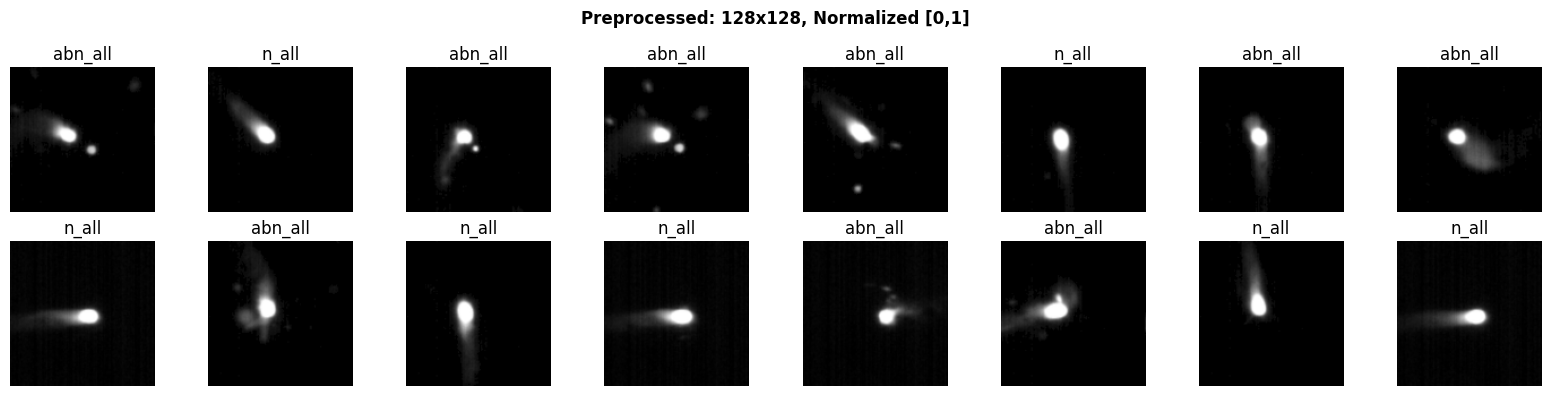

In [15]:
# Show the 16 test images in a grid
# Verify they look correct after preprocessing

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_batch[i])
    ax.set_title(pipeline.class_names[y_batch[i]])
    ax.axis('off')
plt.suptitle('Preprocessed: 128x128, Normalized [0,1]', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Load ALL images using the pipeline
# X = the image data (pixels)
# y = the labels (which class each image belongs to)

X, y = pipeline.load_all()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Loading 200/1200...
Loading 400/1200...
Loading 600/1200...
Loading 800/1200...
Loading 1000/1200...
Loading 1200/1200...
X shape: (1200, 128, 128, 3)
y shape: (1200,)


In [17]:
# Shuffle the data randomly so classes are mixed
# Split into 80% training, 20% testing
# Training = what the model learns from
# Testing = what I use to check if the model works

np.random.seed(42)
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (960, 128, 128, 3), X_test: (240, 128, 128, 3)
y_train: (960,), y_test: (240,)


In [18]:
# Double-check the preprocessing worked:
# - Size should be 128x128
# - Channels should be 3 (RGB)
# - Pixels should be between 0 and 1
# - Data type should be float32

print("Preprocessing Summary:")
print(f"  Size: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"  Channels: {X_train.shape[3]}")
print(f"  Normalized: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  Dtype: {X_train.dtype}")

Preprocessing Summary:
  Size: 128x128
  Channels: 3
  Normalized: [0.000, 1.000]
  Dtype: float32


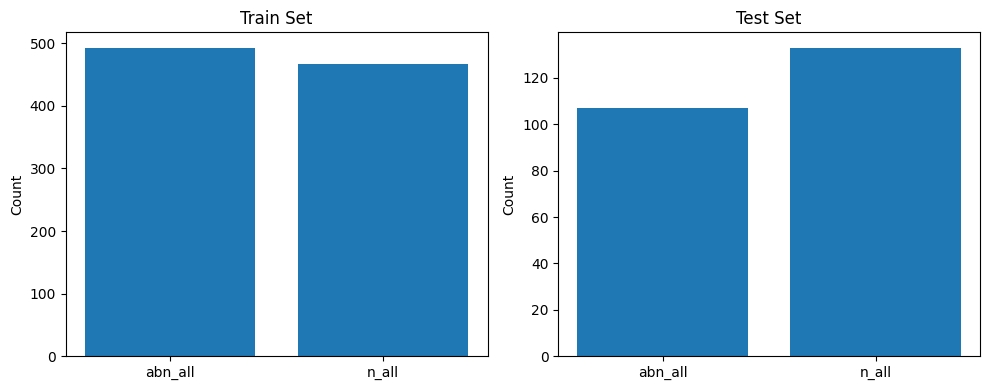

In [19]:
# Show bar charts of how many images are in each class
# Check that train and test sets both have balanced classes

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (data, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = [np.sum(data == i) for i in range(len(pipeline.class_names))]
    ax.bar(pipeline.class_names, counts)
    ax.set_title(f'{title} Set')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [20]:
# Save everything to a file so I don't have to reprocess next time
# The .npz file contains X_train, X_test, y_train, y_test, and class names

output_path = Derived_DIR / "preprocessed_data.npz"
np.savez_compressed(output_path, X_train=X_train, X_test=X_test, 
                    y_train=y_train, y_test=y_test,
                    class_names=pipeline.class_names)
print(f"Saved: {output_path}")

Saved: ../data/derived/preprocessed_data.npz


In [21]:
pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
# sklearn is the main machine learning library
# I need:
# - RandomForestClassifier: the model I'll train
# - accuracy_score: checks what percent I got right
# - classification_report: shows detailed performance per class
# - confusion_matrix: shows what the model got right vs wrong

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
# sklearn expects 2D input: (num_samples, num_features)
# My images are 4D: (num_samples, height, width, channels)
# I need to flatten each image into one long row of numbers
#
# Example: one 128x128x3 image becomes one row of 49152 numbers
# (128 * 128 * 3 = 49152)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")

Original shape: (960, 128, 128, 3)
Flattened shape: (960, 49152)


In [24]:
# Random Forest = many decision trees that vote together
# 
# Parameters I'm setting:
# - n_estimators=100: use 100 trees (more = better but slower)
# - random_state=42: makes results reproducible (same every run)
# - n_jobs=-1: use all CPU cores to train faster

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Model created")
print(f"Number of trees: {model.n_estimators}")

Model created
Number of trees: 100


In [25]:
# fit() is where the model learns from the training data
# X_train_flat = the images (input)
# y_train = the labels (what I want it to predict)
# This may take a minute or two

print("Training started...")
model.fit(X_train_flat, y_train)
print("Training complete!")

Training started...
Training complete!


In [26]:
# predict() uses the trained model to guess labels for new images
# The model has never seen X_test_flat before

y_pred = model.predict(X_test_flat)

print(f"Made {len(y_pred)} predictions")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

Made 240 predictions
First 10 predictions: [1 1 0 1 0 1 0 1 1 1]
First 10 actual labels: [1 1 0 0 0 1 0 1 1 1]


In [27]:
# Accuracy = what percent did the model get right
# Example: 0.85 means 85% correct

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"That means {accuracy * 100:.1f}% of predictions were correct")

Accuracy: 0.9125
That means 91.2% of predictions were correct


In [28]:
# This breaks down performance by class:
# - precision: when it predicted this class, how often was it right?
# - recall: of all actual images in this class, how many did it find?
# - f1-score: combines precision and recall into one number
# - support: how many images of this class were in the test set

print("Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=pipeline.class_names))

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

     abn_all       0.92      0.88      0.90       107
       n_all       0.91      0.94      0.92       133

    accuracy                           0.91       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.91      0.91      0.91       240



In [29]:
# Shows exactly what the model predicted vs actual:
# - Rows = actual class
# - Columns = predicted class
# - Diagonal = correct predictions
# - Off-diagonal = mistakes

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print(f"Reading the matrix:")
print(f"  {pipeline.class_names[0]} correctly predicted: {cm[0,0]}")
print(f"  {pipeline.class_names[0]} incorrectly predicted as {pipeline.class_names[1]}: {cm[0,1]}")
print(f"  {pipeline.class_names[1]} correctly predicted: {cm[1,1]}")
print(f"  {pipeline.class_names[1]} incorrectly predicted as {pipeline.class_names[0]}: {cm[1,0]}")


Confusion Matrix:
[[ 94  13]
 [  8 125]]

Reading the matrix:
  abn_all correctly predicted: 94
  abn_all incorrectly predicted as n_all: 13
  n_all correctly predicted: 125
  n_all incorrectly predicted as abn_all: 8


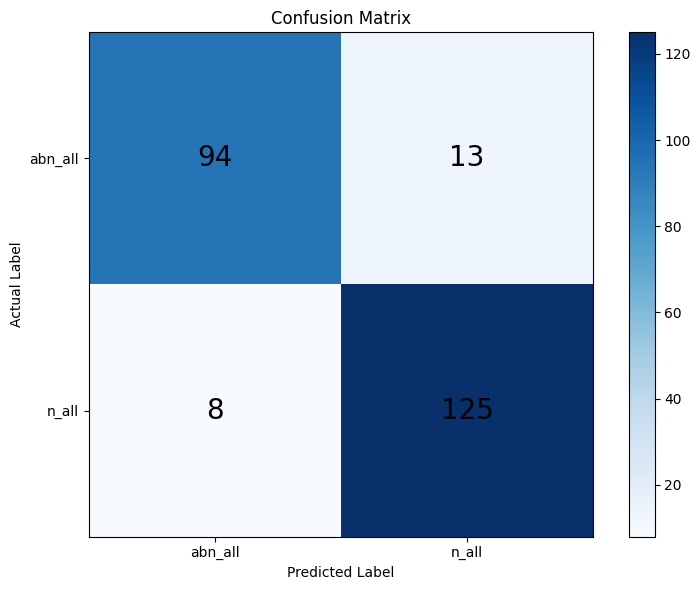

In [30]:
# Easier to read as a heatmap
# Darker color = higher number

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(pipeline.class_names)
ax.set_yticklabels(pipeline.class_names)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix')

# Add numbers to each cell
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20)

plt.colorbar(im)
plt.tight_layout()
plt.show()

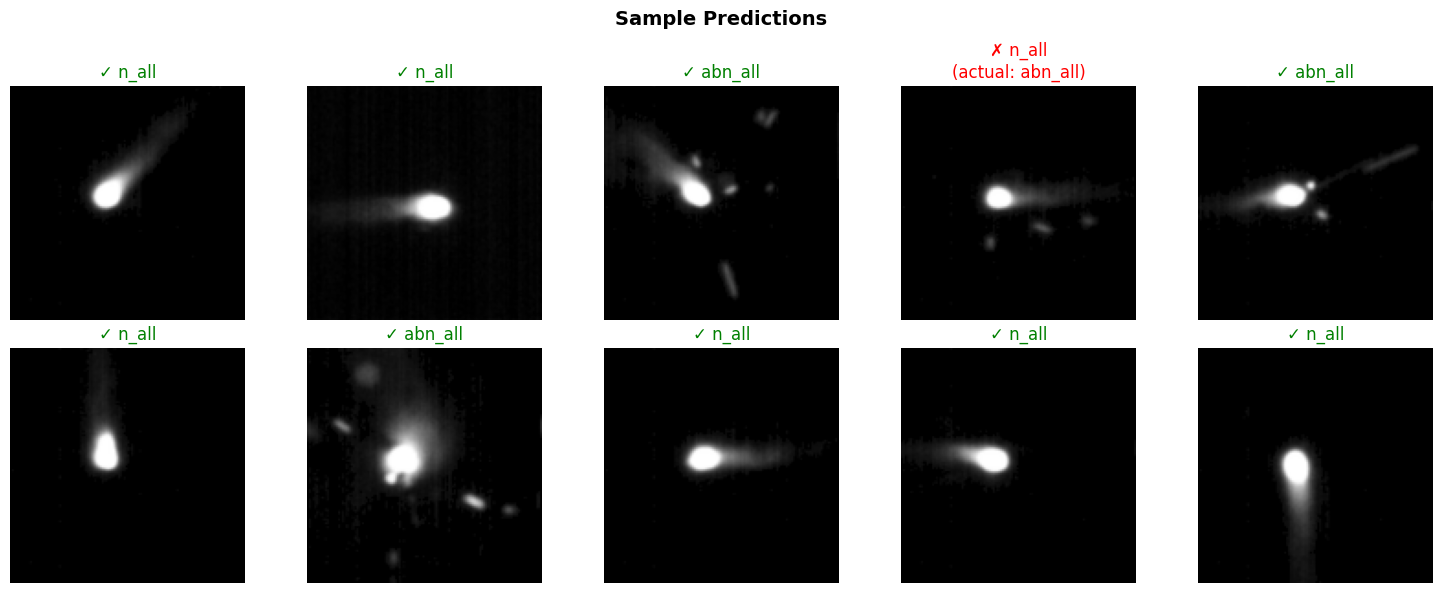

In [31]:
# Pick a few test images and show what the model predicted
# Green title = correct, Red title = wrong

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_test[i])
    
    actual = pipeline.class_names[y_test[i]]
    predicted = pipeline.class_names[y_pred[i]]
    
    if actual == predicted:
        color = 'green'
        title = f"✓ {predicted}"
    else:
        color = 'red'
        title = f"✗ {predicted}\n(actual: {actual})"
    
    axes[i].set_title(title, color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Logistic Regression is simpler and faster
# Good to compare against Random Forest

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Random Forest Accuracy: {accuracy:.4f}")

/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklea

Logistic Regression Accuracy: 0.8000
Random Forest Accuracy: 0.9125


/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andrew/Downloads/UROP-smart-manufacturing/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [33]:
# SVM often works well for image classification
# Can be slow on large datasets

from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train_flat, y_train)
y_pred_svm = model_svm.predict(X_test_flat)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"Random Forest Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

SVM Accuracy: 0.8917
Random Forest Accuracy: 0.9125
Logistic Regression Accuracy: 0.8000


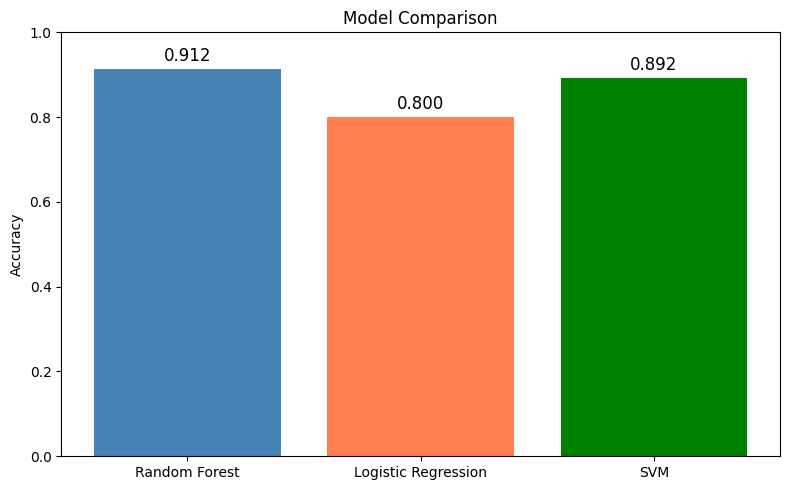

In [34]:
# Bar chart showing the accuracy of each model

models = ['Random Forest', 'Logistic Regression', 'SVM']
accuracies = [accuracy, accuracy_lr, accuracy_svm]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=['steelblue', 'coral', 'green'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison')
ax.set_ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.3f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [35]:
# joblib saves the trained model to a file
# Later I can load it without retraining

import joblib

model_path = Derived_DIR / "random_forest_model.joblib"
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../data/derived/random_forest_model.joblib


In [36]:
# This is how I would use the model later

loaded_model = joblib.load(model_path)

# Predict on one image
single_image = X_test_flat[0:1]  # Need 2D shape, so [0:1] not [0]
prediction = loaded_model.predict(single_image)
print(f"Prediction: {pipeline.class_names[prediction[0]]}")
print(f"Actual: {pipeline.class_names[y_test[0]]}")

Prediction: n_all
Actual: n_all
